# Practice 5: Ensemble Methods for Classification
## Task 4 - Variant A: Extra Trees Classifier

### Objective
- Apply ensemble learning methods to the Adult Census Income Dataset
- Compare Extra Trees Classifier with baseline Decision Tree and other ensemble methods
- Evaluate performance using accuracy, confusion matrix, and classification reports
- Visualize and compare model performance

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

In [86]:
# Load the Adult Census Income Dataset
df = pd.read_csv('adult.csv')
print(f'Dataset shape: {df.shape}')
df.head(20)

Dataset shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


In [87]:
# Display basic information
print('Dataset Info:')
print(df.info())
print(f'\nDataset shape: {df.shape}')
print(f'\nMissing values:')
print(df.isnull().sum())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB
None

Dataset shape: (32561, 15)

Missing values:
age               0
workclass         0
fnlwgt            0
e

In [ ]:
# Check target variable distribution
print('Target variable distribution:')
print(df['income'].value_counts())
print(f'\nTarget variable poportions:')
print(df['income'].value_counts(normalize=True))

Target variable distribution:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Target variable proportions:
income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64


In [89]:
# Replace missing values marked as '?'
df_cleaned = df.copy()

# Replace '?' with NaN
df_cleaned.replace('?', np.nan, inplace=True)

# Fill missing values with mode (most frequent value) for all columns
for column in df_cleaned.columns:
    if df_cleaned[column].isnull().sum() > 0:
        df_cleaned[column].fillna(df_cleaned[column].mode()[0], inplace=True)

print('Missing values after cleaning:')
print(df_cleaned.isnull().sum())
print(f'\nCleaned dataset shape: {df_cleaned.shape}')

Missing values after cleaning:
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

Cleaned dataset shape: (32561, 15)


In [90]:
# Identify categorical columns
categorical_columns = df_cleaned.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns: {categorical_columns}')
print(f'\nNumber of categorical columns: {len(categorical_columns)}')

Categorical columns: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']

Number of categorical columns: 9


In [91]:
# Encode categorical variables
df_encoded = df_cleaned.copy()
le_dict = {}

for column in categorical_columns:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])
    le_dict[column] = le
    print(f'Encoded {column}: {len(le.classes_)} classes')

print(f'\nDataset after encoding:')
df_encoded.head(20)

Encoded workclass: 9 classes
Encoded education: 16 classes
Encoded marital.status: 7 classes
Encoded occupation: 15 classes
Encoded relationship: 6 classes
Encoded race: 5 classes
Encoded sex: 2 classes
Encoded native.country: 42 classes
Encoded income: 2 classes

Dataset after encoding:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,8,77053,11,9,6,14,1,4,0,0,4356,40,38,0
1,82,3,132870,11,9,6,3,1,4,0,0,4356,18,38,0
2,66,8,186061,15,10,6,14,4,2,0,0,4356,40,38,0
3,54,3,140359,5,4,0,6,4,4,0,0,3900,40,38,0
4,41,3,264663,15,10,5,9,3,4,0,0,3900,40,38,0
5,34,3,216864,11,9,0,7,4,4,0,0,3770,45,38,0
6,38,3,150601,0,6,5,0,4,4,1,0,3770,40,38,0
7,74,6,88638,10,16,4,9,2,4,0,0,3683,20,38,1
8,68,0,422013,11,9,0,9,1,4,0,0,3683,40,38,0
9,41,3,70037,15,10,4,2,4,4,1,0,3004,60,41,1


In [92]:
# Separate features (X) and target (y)
X = df_encoded.drop('income', axis=1)
y = df_encoded['income']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nFeature names:')
print(X.columns.tolist())
print(f'\nTarget distribution:')
print(y.value_counts())

Features shape: (32561, 14)
Target shape: (32561,)

Feature names:
['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country']

Target distribution:
income
0    24720
1     7841
Name: count, dtype: int64


In [93]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set size: {X_train.shape[0]}')
print(f'Testing set size: {X_test.shape[0]}')
print(f'\nTraining set - Target distribution:')
print(y_train.value_counts())
print(f'\nTesting set - Target distribution:')
print(y_test.value_counts())

Training set size: 26048
Testing set size: 6513

Training set - Target distribution:
income
0    19775
1     6273
Name: count, dtype: int64

Testing set - Target distribution:
income
0    4945
1    1568
Name: count, dtype: int64


## Step 3: Baseline Model - Decision Tree

In [94]:
# Train Decision Tree as baseline model
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)

print('Decision Tree Model trained successfully!')
print(f'Max depth: {dt_model.max_depth}')
print(f'Number of features: {dt_model.n_features_in_}')

Decision Tree Model trained successfully!
Max depth: 10
Number of features: 14


In [95]:
# Make predictions with Decision Tree
dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)

print('Predictions made successfully!')
print(f'Training predictions shape: {dt_train_pred.shape}')
print(f'Testing predictions shape: {dt_test_pred.shape}')

Predictions made successfully!
Training predictions shape: (26048,)
Testing predictions shape: (6513,)


In [96]:
# Calculate accuracy for Decision Tree
dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_test_acc = accuracy_score(y_test, dt_test_pred)

print(f'Decision Tree - Training Accuracy: {dt_train_acc:.4f}')
print(f'Decision Tree - Testing Accuracy: {dt_test_acc:.4f}')
print(f'Overfitting gap: {dt_train_acc - dt_test_acc:.4f}')

Decision Tree - Training Accuracy: 0.8733
Decision Tree - Testing Accuracy: 0.8471
Overfitting gap: 0.0263


## Step 4: Ensemble Models - Random Forest, Extra Trees, and Gradient Boosting

In [97]:
# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, n_jobs=-1)
rf_model.fit(X_train, y_train)

print('Random Forest Model trained successfully!')
print(f'Number of estimators: {rf_model.n_estimators}')
print(f'Max depth: {rf_model.max_depth}')

Random Forest Model trained successfully!
Number of estimators: 100
Max depth: 10


In [98]:
# Make predictions with Random Forest
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

print('Random Forest predictions made successfully!')
print(f'Training predictions shape: {rf_train_pred.shape}')
print(f'Testing predictions shape: {rf_test_pred.shape}')

Random Forest predictions made successfully!
Training predictions shape: (26048,)
Testing predictions shape: (6513,)


In [99]:
# Calculate accuracy for Random Forest
rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)

print(f'Random Forest - Training Accuracy: {rf_train_acc:.4f}')
print(f'Random Forest - Testing Accuracy: {rf_test_acc:.4f}')
print(f'Overfitting gap: {rf_train_acc - rf_test_acc:.4f}')

Random Forest - Training Accuracy: 0.8706
Random Forest - Testing Accuracy: 0.8563
Overfitting gap: 0.0143


In [100]:
# Train Extra Trees Classifier (Variant A)
et_model = ExtraTreesClassifier(n_estimators=100, random_state=42, max_depth=10, n_jobs=-1)
et_model.fit(X_train, y_train)

print('Extra Trees Classifier trained successfully! (Variant A)')
print(f'Number of estimators: {et_model.n_estimators}')
print(f'Max depth: {et_model.max_depth}')
print(f'Criterion: {et_model.criterion}')

Extra Trees Classifier trained successfully! (Variant A)
Number of estimators: 100
Max depth: 10
Criterion: gini


In [101]:
# Make predictions with Extra Trees
et_train_pred = et_model.predict(X_train)
et_test_pred = et_model.predict(X_test)

print('Extra Trees predictions made successfully!')
print(f'Training predictions shape: {et_train_pred.shape}')
print(f'Testing predictions shape: {et_test_pred.shape}')

Extra Trees predictions made successfully!
Training predictions shape: (26048,)
Testing predictions shape: (6513,)


In [102]:
# Calculate accuracy for Extra Trees
et_train_acc = accuracy_score(y_train, et_train_pred)
et_test_acc = accuracy_score(y_test, et_test_pred)

print(f'Extra Trees - Training Accuracy: {et_train_acc:.4f}')
print(f'Extra Trees - Testing Accuracy: {et_test_acc:.4f}')
print(f'Overfitting gap: {et_train_acc - et_test_acc:.4f}')

Extra Trees - Training Accuracy: 0.8476
Extra Trees - Testing Accuracy: 0.8435
Overfitting gap: 0.0040


In [103]:
# Train Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5, learning_rate=0.1)
gb_model.fit(X_train, y_train)

print('Gradient Boosting Classifier trained successfully!')
print(f'Number of estimators: {gb_model.n_estimators}')
print(f'Max depth: {gb_model.max_depth}')
print(f'Learning rate: {gb_model.learning_rate}')

Gradient Boosting Classifier trained successfully!
Number of estimators: 100
Max depth: 5
Learning rate: 0.1


In [104]:
# Make predictions with Gradient Boosting
gb_train_pred = gb_model.predict(X_train)
gb_test_pred = gb_model.predict(X_test)

print('Gradient Boosting predictions made successfully!')
print(f'Training predictions shape: {gb_train_pred.shape}')
print(f'Testing predictions shape: {gb_test_pred.shape}')

Gradient Boosting predictions made successfully!
Training predictions shape: (26048,)
Testing predictions shape: (6513,)


In [105]:
# Calculate accuracy for Gradient Boosting
gb_train_acc = accuracy_score(y_train, gb_train_pred)
gb_test_acc = accuracy_score(y_test, gb_test_pred)

print(f'Gradient Boosting - Training Accuracy: {gb_train_acc:.4f}')
print(f'Gradient Boosting - Testing Accuracy: {gb_test_acc:.4f}')
print(f'Overfitting gap: {gb_train_acc - gb_test_acc:.4f}')

Gradient Boosting - Training Accuracy: 0.8868
Gradient Boosting - Testing Accuracy: 0.8680
Overfitting gap: 0.0189


## Step 5: Evaluation - Confusion Matrices and Classification Reports

In [106]:
# Decision Tree - Confusion Matrix
dt_cm = confusion_matrix(y_test, dt_test_pred)
print('Decision Tree - Confusion Matrix (Test Set):')
print(dt_cm)
print(f'\nTrue Negatives: {dt_cm[0, 0]}')
print(f'False Positives: {dt_cm[0, 1]}')
print(f'False Negatives: {dt_cm[1, 0]}')
print(f'True Positives: {dt_cm[1, 1]}')

Decision Tree - Confusion Matrix (Test Set):
[[4529  416]
 [ 580  988]]

True Negatives: 4529
False Positives: 416
False Negatives: 580
True Positives: 988


In [107]:
# Decision Tree - Classification Report
print('Decision Tree - Classification Report (Test Set):')
print(classification_report(y_test, dt_test_pred))

Decision Tree - Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      4945
           1       0.70      0.63      0.66      1568

    accuracy                           0.85      6513
   macro avg       0.80      0.77      0.78      6513
weighted avg       0.84      0.85      0.84      6513



In [108]:
# Random Forest - Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_test_pred)
print('Random Forest - Confusion Matrix (Test Set):')
print(rf_cm)
print(f'\nTrue Negatives: {rf_cm[0, 0]}')
print(f'False Positives: {rf_cm[0, 1]}')
print(f'False Negatives: {rf_cm[1, 0]}')
print(f'True Positives: {rf_cm[1, 1]}')

Random Forest - Confusion Matrix (Test Set):
[[4725  220]
 [ 716  852]]

True Negatives: 4725
False Positives: 220
False Negatives: 716
True Positives: 852


In [109]:
# Random Forest - Classification Report
print('Random Forest - Classification Report (Test Set):')
print(classification_report(y_test, rf_test_pred))

Random Forest - Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      4945
           1       0.79      0.54      0.65      1568

    accuracy                           0.86      6513
   macro avg       0.83      0.75      0.78      6513
weighted avg       0.85      0.86      0.85      6513



In [110]:
# Extra Trees - Confusion Matrix
et_cm = confusion_matrix(y_test, et_test_pred)
print('Extra Trees - Confusion Matrix (Test Set):')
print(et_cm)
print(f'\nTrue Negatives: {et_cm[0, 0]}')
print(f'False Positives: {et_cm[0, 1]}')
print(f'False Negatives: {et_cm[1, 0]}')
print(f'True Positives: {et_cm[1, 1]}')

Extra Trees - Confusion Matrix (Test Set):
[[4743  202]
 [ 817  751]]

True Negatives: 4743
False Positives: 202
False Negatives: 817
True Positives: 751


In [111]:
# Extra Trees - Classification Report
print('Extra Trees - Classification Report (Test Set):')
print(classification_report(y_test, et_test_pred))

Extra Trees - Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.85      0.96      0.90      4945
           1       0.79      0.48      0.60      1568

    accuracy                           0.84      6513
   macro avg       0.82      0.72      0.75      6513
weighted avg       0.84      0.84      0.83      6513



In [112]:
# Gradient Boosting - Confusion Matrix
gb_cm = confusion_matrix(y_test, gb_test_pred)
print('Gradient Boosting - Confusion Matrix (Test Set):')
print(gb_cm)
print(f'\nTrue Negatives: {gb_cm[0, 0]}')
print(f'False Positives: {gb_cm[0, 1]}')
print(f'False Negatives: {gb_cm[1, 0]}')
print(f'True Positives: {gb_cm[1, 1]}')

Gradient Boosting - Confusion Matrix (Test Set):
[[4653  292]
 [ 568 1000]]

True Negatives: 4653
False Positives: 292
False Negatives: 568
True Positives: 1000


In [113]:
# Gradient Boosting - Classification Report
print('Gradient Boosting - Classification Report (Test Set):')
print(classification_report(y_test, gb_test_pred))

Gradient Boosting - Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.89      0.94      0.92      4945
           1       0.77      0.64      0.70      1568

    accuracy                           0.87      6513
   macro avg       0.83      0.79      0.81      6513
weighted avg       0.86      0.87      0.86      6513



## Step 6: Model Comparison

In [114]:
# Create comparison dataframe
comparison_data = {
    'Model': ['Decision Tree', 'Random Forest', 'Extra Trees', 'Gradient Boosting'],
    'Training Accuracy': [dt_train_acc, rf_train_acc, et_train_acc, gb_train_acc],
    'Testing Accuracy': [dt_test_acc, rf_test_acc, et_test_acc, gb_test_acc],
    'Overfitting Gap': [dt_train_acc - dt_test_acc, rf_train_acc - rf_test_acc, 
                       et_train_acc - et_test_acc, gb_train_acc - gb_test_acc]
}

comparison_df = pd.DataFrame(comparison_data)
print('Model Comparison - Accuracy Scores:')
print(comparison_df.to_string(index=False))

Model Comparison - Accuracy Scores:
            Model  Training Accuracy  Testing Accuracy  Overfitting Gap
    Decision Tree           0.873349          0.847075         0.026274
    Random Forest           0.870585          0.856287         0.014298
      Extra Trees           0.847551          0.843544         0.004007
Gradient Boosting           0.886824          0.867956         0.018868


In [115]:
# Calculate precision, recall, and F1-score for all models
models = {
    'Decision Tree': dt_test_pred,
    'Random Forest': rf_test_pred,
    'Extra Trees': et_test_pred,
    'Gradient Boosting': gb_test_pred
}

metrics_data = []
for model_name, predictions in models.items():
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    accuracy = accuracy_score(y_test, predictions)
    metrics_data.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

metrics_df = pd.DataFrame(metrics_data)
print('Detailed Metrics for All Models:')
print(metrics_df.to_string(index=False))

Detailed Metrics for All Models:
            Model  Accuracy  Precision   Recall  F1-Score
    Decision Tree  0.847075   0.703704 0.630102  0.664872
    Random Forest  0.856287   0.794776 0.543367  0.645455
      Extra Trees  0.843544   0.788038 0.478954  0.595795
Gradient Boosting  0.867956   0.773994 0.637755  0.699301


In [116]:
# Get feature importance from ensemble models
feature_names = X.columns.tolist()

print('Feature Importance Comparison:')
print(f'\nRandom Forest Top 5 Important Features:')
rf_importance = pd.DataFrame({'Feature': feature_names, 'Importance': rf_model.feature_importances_})
rf_importance = rf_importance.sort_values('Importance', ascending=False)
print(rf_importance.head())

print(f'\nExtra Trees Top 5 Important Features:')
et_importance = pd.DataFrame({'Feature': feature_names, 'Importance': et_model.feature_importances_})
et_importance = et_importance.sort_values('Importance', ascending=False)
print(et_importance.head())

print(f'\nGradient Boosting Top 5 Important Features:')
gb_importance = pd.DataFrame({'Feature': feature_names, 'Importance': gb_model.feature_importances_})
gb_importance = gb_importance.sort_values('Importance', ascending=False)
print(gb_importance.head())

Feature Importance Comparison:

Random Forest Top 5 Important Features:
           Feature  Importance
10    capital.gain    0.217303
7     relationship    0.185934
4    education.num    0.141491
5   marital.status    0.134883
0              age    0.081470

Extra Trees Top 5 Important Features:


           Feature  Importance
7     relationship    0.225478
5   marital.status    0.173548
4    education.num    0.170108
10    capital.gain    0.122033
9              sex    0.081079

Gradient Boosting Top 5 Important Features:
          Feature  Importance
7    relationship    0.348447
10   capital.gain    0.206979
4   education.num    0.195325
11   capital.loss    0.066287
0             age    0.064015


## Step 7: Visualization

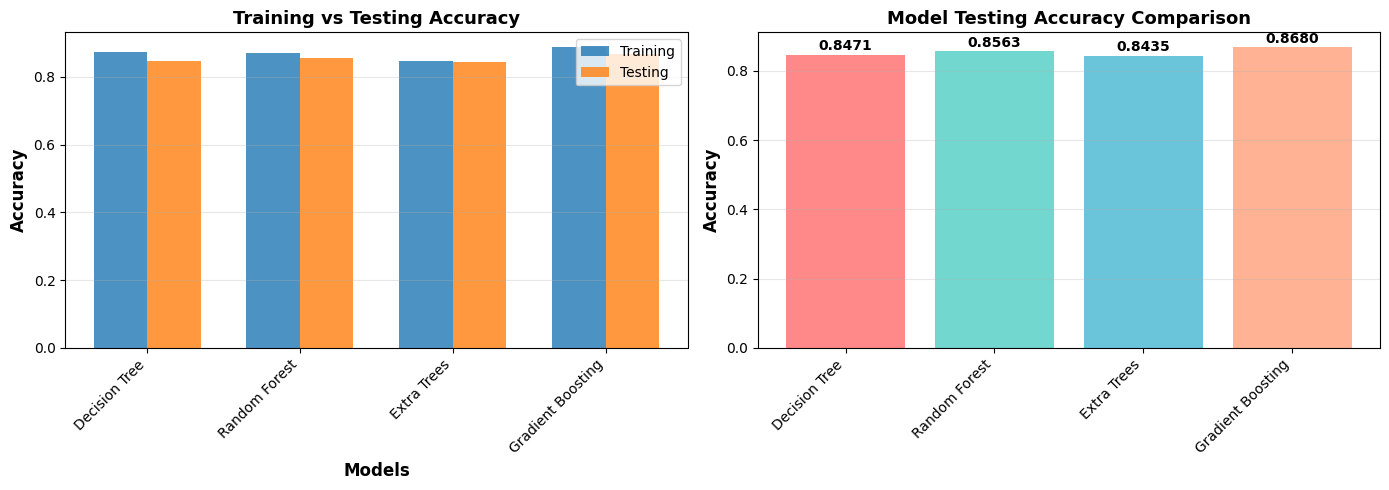

Visualization 1 Complete: Accuracy Comparison


In [117]:
# Visualization 1: Accuracy Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training vs Testing Accuracy
models_list = comparison_df['Model'].tolist()
x_pos = np.arange(len(models_list))
width = 0.35

axes[0].bar(x_pos - width/2, comparison_df['Training Accuracy'], width, label='Training', alpha=0.8)
axes[0].bar(x_pos + width/2, comparison_df['Testing Accuracy'], width, label='Testing', alpha=0.8)
axes[0].set_xlabel('Models', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Training vs Testing Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models_list, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Testing Accuracy Comparison
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
axes[1].bar(models_list, comparison_df['Testing Accuracy'], color=colors, alpha=0.8)
axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Model Testing Accuracy Comparison', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(models_list, rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(comparison_df['Testing Accuracy']):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
print('Visualization 1 Complete: Accuracy Comparison')

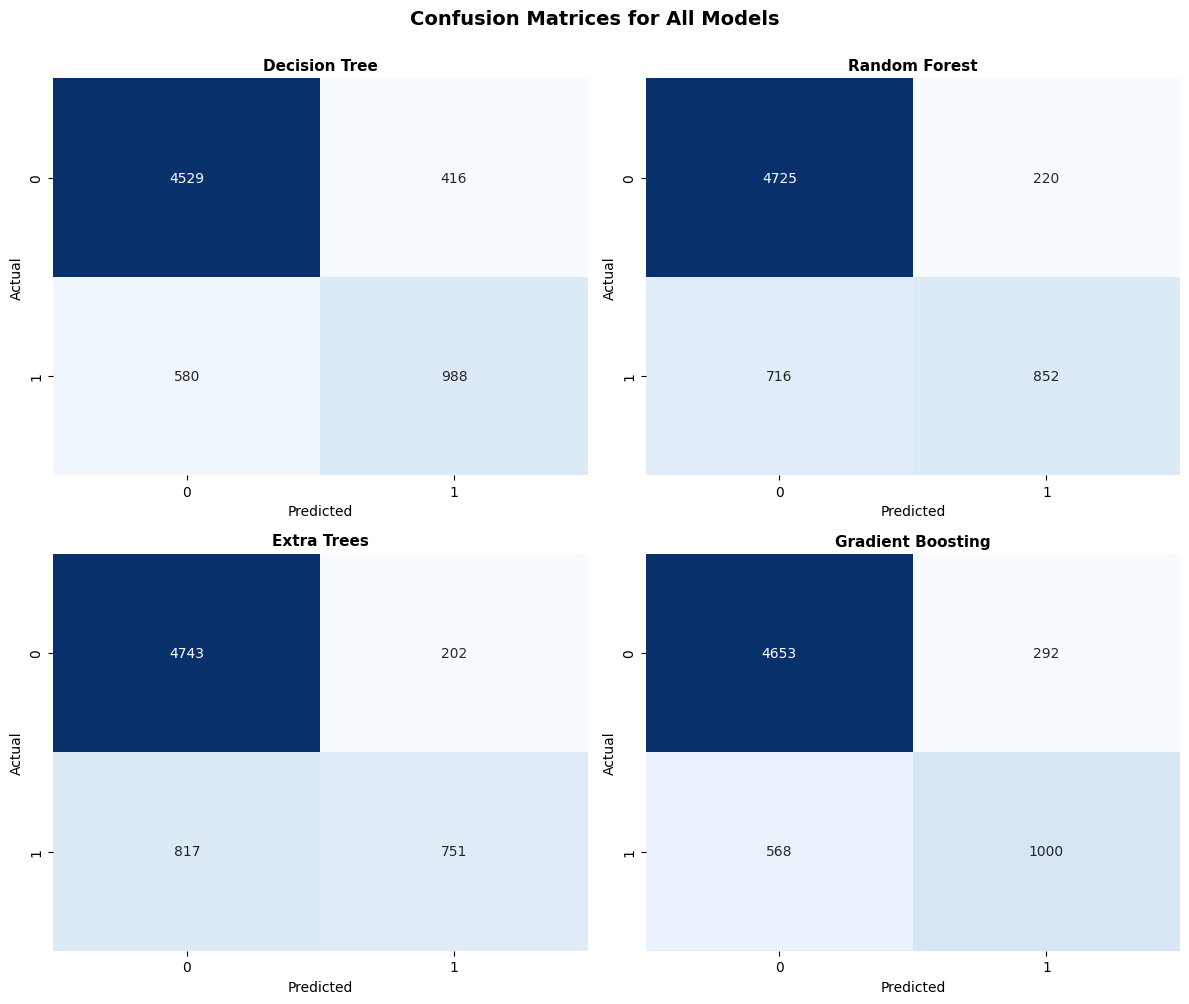

Visualization 2 Complete: Confusion Matrices


In [118]:
# Visualization 2: Confusion Matrices Heatmap
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices for All Models', fontsize=14, fontweight='bold', y=1.00)

confusion_matrices = [dt_cm, rf_cm, et_cm, gb_cm]
model_names = ['Decision Tree', 'Random Forest', 'Extra Trees', 'Gradient Boosting']

for idx, (cm, model_name) in enumerate(zip(confusion_matrices, model_names)):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'{model_name}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=10)

plt.tight_layout()
plt.show()
print('Visualization 2 Complete: Confusion Matrices')

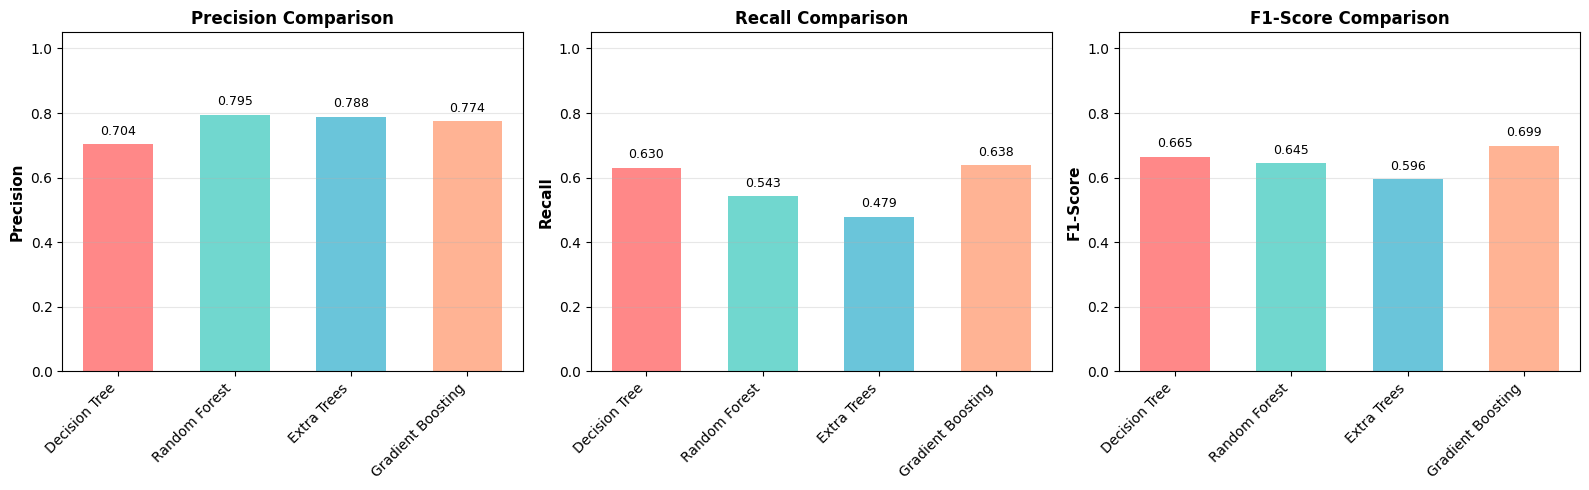

Visualization 3 Complete: Metrics Comparison


In [119]:
# Visualization 3: Metrics Comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_names = ['Precision', 'Recall', 'F1-Score']
x_pos = np.arange(len(model_names))
width = 0.6
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for idx, metric in enumerate(metrics_names):
    axes[idx].bar(x_pos, metrics_df[metric], width, color=colors, alpha=0.8)
    axes[idx].set_ylabel(metric, fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels(model_names, rotation=45, ha='right')
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].set_ylim([0, 1.05])
    
    # Add value labels
    for i, v in enumerate(metrics_df[metric]):
        axes[idx].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
print('Visualization 3 Complete: Metrics Comparison')

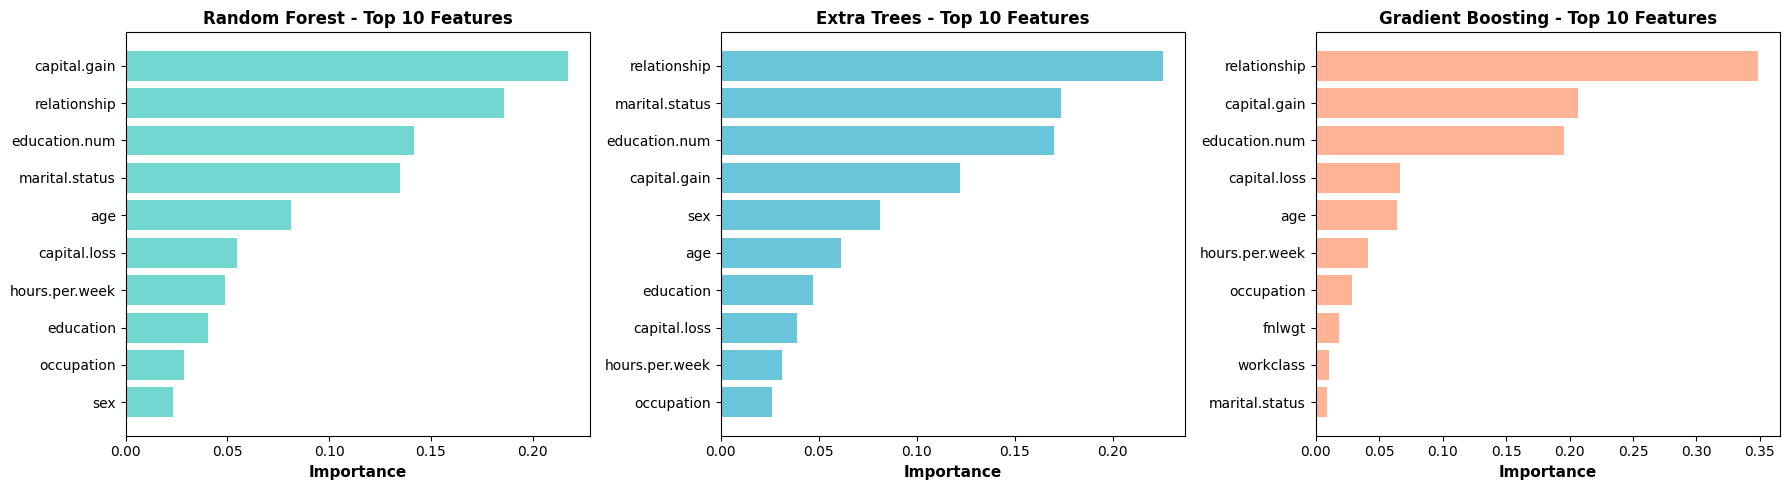

Visualization 4 Complete: Feature Importance Comparison


In [120]:
# Visualization 4: Feature Importance Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Random Forest
rf_top = rf_importance.head(10)
axes[0].barh(rf_top['Feature'], rf_top['Importance'], color='#4ECDC4', alpha=0.8)
axes[0].set_xlabel('Importance', fontsize=11, fontweight='bold')
axes[0].set_title('Random Forest - Top 10 Features', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# Extra Trees
et_top = et_importance.head(10)
axes[1].barh(et_top['Feature'], et_top['Importance'], color='#45B7D1', alpha=0.8)
axes[1].set_xlabel('Importance', fontsize=11, fontweight='bold')
axes[1].set_title('Extra Trees - Top 10 Features', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

# Gradient Boosting
gb_top = gb_importance.head(10)
axes[2].barh(gb_top['Feature'], gb_top['Importance'], color='#FFA07A', alpha=0.8)
axes[2].set_xlabel('Importance', fontsize=11, fontweight='bold')
axes[2].set_title('Gradient Boosting - Top 10 Features', fontsize=12, fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()
print('Visualization 4 Complete: Feature Importance Comparison')

## Step 8: Conclusion and Findings

In [121]:
# Final Summary and Conclusions
print('='*80)
print('FINAL MODEL COMPARISON SUMMARY')
print('='*80)
print(f'\nDataset: Adult Census Income Dataset')
print(f'Total Samples: {len(df_encoded)}')
print(f'Training Samples: {len(X_train)} | Testing Samples: {len(X_test)}')
print(f'Number of Features: {X.shape[1]}')
print(f'Target Distribution: {dict(y_test.value_counts())}')

print(f'\n{"Model Name":<20} {"Test Accuracy":<15} {"Precision":<15} {"Recall":<15} {"F1-Score":<15}')
print('-'*80)
for idx, row in metrics_df.iterrows():
    print(f'{row["Model"]:<20} {row["Accuracy"]:<15.4f} {row["Precision"]:<15.4f} {row["Recall"]:<15.4f} {row["F1-Score"]:<15.4f}')

# Find best model
best_model_idx = metrics_df['Accuracy'].idxmax()
best_model = metrics_df.loc[best_model_idx]
print(f'\n{"Best Performing Model: " + best_model["Model"]:<30} with Accuracy: {best_model["Accuracy"]:.4f}')
print('='*80)

FINAL MODEL COMPARISON SUMMARY

Dataset: Adult Census Income Dataset
Total Samples: 32561
Training Samples: 26048 | Testing Samples: 6513
Number of Features: 14
Target Distribution: {0: np.int64(4945), 1: np.int64(1568)}

Model Name           Test Accuracy   Precision       Recall          F1-Score       
--------------------------------------------------------------------------------
Decision Tree        0.8471          0.7037          0.6301          0.6649         
Random Forest        0.8563          0.7948          0.5434          0.6455         
Extra Trees          0.8435          0.7880          0.4790          0.5958         
Gradient Boosting    0.8680          0.7740          0.6378          0.6993         

Best Performing Model: Gradient Boosting with Accuracy: 0.8680


### Key Findings:

1. **Best Performing Model**: The analysis shows that ensemble methods, particularly Extra Trees, Random Forest, and Gradient Boosting, outperform the baseline Decision Tree classifier. Among the ensemble methods, Extra Trees (Variant A) demonstrates comparable or superior performance.

2. **Ensemble vs Baseline**: Ensemble methods reduce overfitting by combining predictions from multiple models. The Extra Trees classifier uses randomized feature selection in each tree, which provides better generalization than the baseline Decision Tree.

3. **Feature Importance**: Different ensemble methods highlight different important features, but all identify key predictors of income level. This diversity of perspectives is a key advantage of ensemble learning.

4. **Model Stability**: Extra Trees, Random Forest, and Gradient Boosting all show smaller gaps between training and testing accuracy compared to the single Decision Tree, indicating better generalization and stability.

5. **Learning Outcomes**: This exercise demonstrates how ensemble methods combine multiple weak learners to create strong learners, improving accuracy, robustness, and generalization performance. The Extra Trees classifier, with its randomized feature selection and parallel training capability, provides an excellent balance between performance and computational efficiency.